# F1 Strategy Prediction (Diagram-Aligned: GRU + MLP + Multi-Task Heads)

This notebook implements the architecture from your diagram:

1. **Weather forecast sequence encoder** (GRU)
2. **Feature embeddings** for team/track/starting compound + numeric race context
3. **Feature fusion** (concatenation)
4. **Multi-task output heads**:
   - Pit stop count (classification)
   - Tire strategy (classification)
   - Time loss (regression)

It uses local files from `openf1_data/` and produces training/validation plots for loss and accuracy.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 1) Config

In [2]:
DATA_DIR = Path("openf1_data")
assert DATA_DIR.exists(), f"Missing openf1_data: {DATA_DIR.resolve()}"

MODEL_FILE = "multitask_strategy_model.keras"
PREPROC_FILE = "multitask_preprocessing.joblib"

RACE_CONTEXT_FILE = "race_context_input.csv"
FORECAST_FILE = "forecast_weather.csv"

WEATHER_FEATURES = [
    "air_temperature",
    "track_temperature",
    "humidity",
    "rainfall",
    "wind_speed",
]

VALID_COMPOUNDS = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]

## 2) Helpers

In [3]:
def parse_session_key(path: Path):
    m = re.search(r"_session_(\d+)\.csv$", path.name)
    return int(m.group(1)) if m else None


def safe_read_csv(path: Path):
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.DataFrame()


def safe_mode(series, default="MEDIUM"):
    s = pd.Series(series).dropna()
    if s.empty:
        return default
    m = s.mode()
    return m.iloc[0] if not m.empty else default

## 3) Load sessions and track map

In [4]:
def load_session_maps():
    sessions = safe_read_csv(DATA_DIR / "sessions.csv")
    if sessions.empty:
        return {}, {}, {}

    for c in ["session_key", "meeting_key", "session_name", "location", "circuit_short_name"]:
        if c not in sessions.columns:
            sessions[c] = np.nan

    meeting_files = list(DATA_DIR.glob("meetings_meeting_*.csv"))
    rows = []
    for f in meeting_files:
        m = safe_read_csv(f)
        if m.empty:
            continue
        for c in ["meeting_key", "meeting_name", "country_name", "location", "circuit_short_name"]:
            if c not in m.columns:
                m[c] = np.nan
        rows.append(m[["meeting_key", "meeting_name", "country_name", "location", "circuit_short_name"]].head(1))

    if rows:
        meetings = pd.concat(rows, ignore_index=True).drop_duplicates("meeting_key")
        sessions = sessions.merge(meetings, on="meeting_key", how="left", suffixes=("", "_m"))
    else:
        sessions["meeting_name"] = np.nan
        sessions["country_name"] = np.nan
        sessions["location_m"] = np.nan
        sessions["circuit_short_name_m"] = np.nan

    sessions["track_name"] = (
        sessions["circuit_short_name"]
        .fillna(sessions["circuit_short_name_m"])
        .fillna(sessions["location"])
        .fillna(sessions["location_m"])
        .fillna(sessions["meeting_name"])
        .fillna(sessions["country_name"])
        .fillna(sessions["meeting_key"].astype(str))
    )

    session_to_track = dict(zip(sessions["session_key"], sessions["track_name"]))
    session_to_meeting = dict(zip(sessions["session_key"], sessions["meeting_key"]))
    session_to_name = dict(zip(sessions["session_key"], sessions["session_name"].astype(str)))
    return session_to_track, session_to_meeting, session_to_name


session_to_track, session_to_meeting, session_to_name = load_session_maps()
len(session_to_track), len(session_to_meeting), len(session_to_name)

(490, 490, 490)

## 4) Build race-level rows + weather sequences from local OpenF1 files

In [5]:
def get_weather_sequence(session_key):
    wf = DATA_DIR / f"weather_session_{session_key}.csv"
    w = safe_read_csv(wf)
    if w.empty:
        return None, None

    for c in WEATHER_FEATURES:
        if c not in w.columns:
            w[c] = np.nan
        w[c] = pd.to_numeric(w[c], errors="coerce")

    w = w.dropna(subset=WEATHER_FEATURES, how="all")
    if w.empty:
        return None, None

    seq = w[WEATHER_FEATURES].fillna(method="ffill").fillna(method="bfill").fillna(0.0).values

    weather_summary = {
        "air_temp_mean": float(w["air_temperature"].mean()),
        "track_temp_mean": float(w["track_temperature"].mean()),
        "humidity_mean": float(w["humidity"].mean()),
        "rain_minutes_ratio": float((w["rainfall"].fillna(0) > 0).mean()),
        "wind_speed_mean": float(w["wind_speed"].mean()),
    }
    return seq, weather_summary


def estimate_time_loss_for_team(session_key, team_name, driver_team_map):
    """
    Proxy target for regression head:
    total pit stationary + entry/exit effect estimated from pit events count * nominal value,
    or sum pit_duration if present.
    """
    pit = safe_read_csv(DATA_DIR / f"pit_session_{session_key}.csv")
    if pit.empty:
        return 0.0

    if "driver_number" not in pit.columns:
        return 0.0

    p = pit.copy()
    p = p.merge(driver_team_map, on="driver_number", how="left")
    p = p[p["team_name"] == team_name]
    if p.empty:
        return 0.0

    # Try duration columns if present
    duration_col = None
    for cand in ["pit_duration", "duration", "pit_time"]:
        if cand in p.columns:
            duration_col = cand
            break

    if duration_col:
        d = pd.to_numeric(p[duration_col], errors="coerce").dropna()
        if len(d):
            # add lane transit buffer
            return float(d.sum() + 15.0 * len(d))

    # fallback nominal per stop
    return float(21.0 * len(p))


def build_training_samples(race_only=True):
    stints_files = sorted(DATA_DIR.glob("stints_session_*.csv"))

    rows = []
    weather_sequences = []

    for sf in stints_files:
        sid = parse_session_key(sf)
        if sid is None:
            continue

        sname = str(session_to_name.get(sid, ""))
        if race_only and ("Race" not in sname and "RACE" not in sname):
            continue

        stints = safe_read_csv(sf)
        if stints.empty:
            continue

        for c in ["driver_number", "compound", "stint_number"]:
            if c not in stints.columns:
                stints[c] = np.nan

        drivers = safe_read_csv(DATA_DIR / f"drivers_session_{sid}.csv")
        if drivers.empty:
            continue
        for c in ["driver_number", "team_name"]:
            if c not in drivers.columns:
                drivers[c] = np.nan

        driver_team = drivers[["driver_number", "team_name"]].dropna().drop_duplicates()
        stints = stints.merge(driver_team, on="driver_number", how="left")

        pits = safe_read_csv(DATA_DIR / f"pit_session_{sid}.csv")
        if pits.empty:
            pits = pd.DataFrame(columns=["driver_number"])
        if "driver_number" not in pits.columns:
            pits["driver_number"] = np.nan
        pits = pits.merge(driver_team, on="driver_number", how="left")

        # starting grid
        grid = safe_read_csv(DATA_DIR / f"starting_grid_session_{sid}.csv")
        grid_pos_col = None
        for cand in ["position", "grid_position"]:
            if cand in grid.columns:
                grid_pos_col = cand
                break

        if not grid.empty and "driver_number" in grid.columns and grid_pos_col is not None:
            g = grid[["driver_number", grid_pos_col]].copy()
            g.columns = ["driver_number", "starting_position"]
            g["starting_position"] = pd.to_numeric(g["starting_position"], errors="coerce")
            g = g.merge(driver_team, on="driver_number", how="left")
            team_start_pos = g.groupby("team_name")["starting_position"].mean().to_dict()
        else:
            team_start_pos = {}

        w_seq, w_summary = get_weather_sequence(sid)
        if w_seq is None:
            continue

        track_name = str(session_to_track.get(sid, session_to_meeting.get(sid, "UNKNOWN_TRACK")))

        for team, t_stints in stints.groupby("team_name", dropna=True):
            if pd.isna(team):
                continue

            team = str(team)
            t_pits = pits[pits["team_name"] == team]
            pit_count = int(len(t_pits))

            stint1 = t_stints[t_stints["stint_number"] == 1]
            if len(stint1):
                start_comp = safe_mode(stint1["compound"], default=safe_mode(t_stints["compound"]))
            else:
                start_comp = safe_mode(t_stints["compound"], default="MEDIUM")
            start_comp = str(start_comp).upper()
            if start_comp not in VALID_COMPOUNDS:
                start_comp = "MEDIUM"

            # tire target: most common non-starting compound if exists, else mode
            non_start = t_stints[t_stints["compound"].astype(str).str.upper() != start_comp]["compound"]
            tire_target = safe_mode(non_start, default=safe_mode(t_stints["compound"], default="MEDIUM"))
            tire_target = str(tire_target).upper()
            if tire_target not in VALID_COMPOUNDS:
                tire_target = "MEDIUM"

            start_pos = team_start_pos.get(team, np.nan)
            if pd.isna(start_pos):
                start_pos = 10.0

            time_loss = estimate_time_loss_for_team(sid, team, driver_team)

            rows.append({
                "session_key": sid,
                "team_name": team,
                "track_name": track_name,
                "starting_position": float(start_pos),
                "starting_compound": start_comp,
                "pit_stops": pit_count,
                "target_compound": tire_target,
                "time_loss_target": float(time_loss),
                **w_summary,
            })
            weather_sequences.append(w_seq)

    df = pd.DataFrame(rows)
    return df, weather_sequences


df, X_seq_raw = build_training_samples(race_only=True)
print("Samples:", len(df), "Sequences:", len(X_seq_raw))
df.head()

/var/folders/zb/tmbpzqhj4dxd92lmpmh07qv40000gn/T/ipykernel_64990/3521354177.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seq = w[WEATHER_FEATURES].fillna(method="ffill").fillna(method="bfill").fillna(0.0).values
/var/folders/zb/tmbpzqhj4dxd92lmpmh07qv40000gn/T/ipykernel_64990/3521354177.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seq = w[WEATHER_FEATURES].fillna(method="ffill").fillna(method="bfill").fillna(0.0).values
/var/folders/zb/tmbpzqhj4dxd92lmpmh07qv40000gn/T/ipykernel_64990/3521354177.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seq = w[WEATHER_FEATURES].fillna(method="ffill").fillna(method="bfill").fillna(0.0).values
/var/folders/zb/tmbpzqhj4dxd92lmpmh07qv40000gn/T/ipykernel_64990

Samples: 90 Sequences: 90


/var/folders/zb/tmbpzqhj4dxd92lmpmh07qv40000gn/T/ipykernel_64990/3521354177.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seq = w[WEATHER_FEATURES].fillna(method="ffill").fillna(method="bfill").fillna(0.0).values


,session_key,team_name,track_name,starting_position,starting_compound,pit_stops,target_compound,time_loss_target,air_temp_mean,track_temp_mean,humidity_mean,rain_minutes_ratio,wind_speed_mean
0,10033,Alpine,Miami,10.0,HARD,1,MEDIUM,37.060,26.573154,38.690604,63.020134,0.033557,1.04698
1,10033,Aston Martin,Miami,10.0,HARD,2,MEDIUM,75.919,26.573154,38.690604,63.020134,0.033557,1.04698
2,10033,Ferrari,Miami,10.0,HARD,2,MEDIUM,75.287,26.573154,38.690604,63.020134,0.033557,1.04698
3,10033,Haas F1 Team,Miami,10.0,HARD,1,MEDIUM,38.162,26.573154,38.690604,63.020134,0.033557,1.04698
4,10033,Kick Sauber,Miami,10.0,HARD,2,MEDIUM,74.296,26.573154,38.690604,63.020134,0.033557,1.04698


## 5) Preprocess inputs/targets

In [6]:
assert len(df) == len(X_seq_raw) and len(df) > 0, "No training data built."

df = df.copy().reset_index(drop=True)

# Encoders
team_enc = LabelEncoder()
track_enc = LabelEncoder()
start_comp_enc = LabelEncoder()
stops_enc = LabelEncoder()
tire_enc = LabelEncoder()

df["team_id"] = team_enc.fit_transform(df["team_name"].astype(str))
df["track_id"] = track_enc.fit_transform(df["track_name"].astype(str))
df["start_comp_id"] = start_comp_enc.fit_transform(df["starting_compound"].astype(str))

y_stops = stops_enc.fit_transform(df["pit_stops"])
y_tire = tire_enc.fit_transform(df["target_compound"].astype(str))
y_time = df["time_loss_target"].astype(float).values

NUM_COLS = [
    "starting_position",
    "air_temp_mean",
    "track_temp_mean",
    "humidity_mean",
    "rain_minutes_ratio",
    "wind_speed_mean",
]
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())

X_num = df[NUM_COLS].values.astype("float32")
X_team = df["team_id"].values.astype("int32")
X_track = df["track_id"].values.astype("int32")
X_start_comp = df["start_comp_id"].values.astype("int32")

X_seq = pad_sequences(X_seq_raw, padding="post", dtype="float32")

print("X_seq shape:", X_seq.shape)
print("X_num shape:", X_num.shape)
print("stop classes:", len(stops_enc.classes_), "tire classes:", len(tire_enc.classes_))

X_seq shape: (90, 201, 5)
X_num shape: (90, 6)
stop classes: 7 tire classes: 5


## 6) Train/val split

In [7]:
idx = np.arange(len(df))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)

def take(a, ids):
    return a[ids]

X_train = {
    "weather_seq": take(X_seq, train_idx),
    "team_in": take(X_team, train_idx),
    "track_in": take(X_track, train_idx),
    "start_comp_in": take(X_start_comp, train_idx),
    "num_in": take(X_num, train_idx),
}

X_val = {
    "weather_seq": take(X_seq, val_idx),
    "team_in": take(X_team, val_idx),
    "track_in": take(X_track, val_idx),
    "start_comp_in": take(X_start_comp, val_idx),
    "num_in": take(X_num, val_idx),
}

y_train = {
    "stops_head": take(y_stops, train_idx),
    "tire_head": take(y_tire, train_idx),
    "time_head": take(y_time, train_idx),
}

y_val = {
    "stops_head": take(y_stops, val_idx),
    "tire_head": take(y_tire, val_idx),
    "time_head": take(y_time, val_idx),
}

## 7) Build diagram-aligned model (GRU + embeddings + fusion + 3 heads)

In [8]:
timesteps = X_seq.shape[1]
weather_feat_dim = X_seq.shape[2]

n_team = len(team_enc.classes_)
n_track = len(track_enc.classes_)
n_start_comp = len(start_comp_enc.classes_)
n_stop_classes = len(stops_enc.classes_)
n_tire_classes = len(tire_enc.classes_)

weather_in = keras.Input(shape=(timesteps, weather_feat_dim), name="weather_seq")
team_in = keras.Input(shape=(1,), dtype="int32", name="team_in")
track_in = keras.Input(shape=(1,), dtype="int32", name="track_in")
start_comp_in = keras.Input(shape=(1,), dtype="int32", name="start_comp_in")
num_in = keras.Input(shape=(len(NUM_COLS),), dtype="float32", name="num_in")

# Sequence encoder
w = layers.GRU(64, name="weather_gru")(weather_in)

# Embeddings
team_e = layers.Embedding(n_team, min(16, max(4, n_team // 2)), name="team_emb")(team_in)
team_e = layers.Reshape((-1,))(team_e)

track_e = layers.Embedding(n_track, min(16, max(4, n_track // 2)), name="track_emb")(track_in)
track_e = layers.Reshape((-1,))(track_e)

start_e = layers.Embedding(n_start_comp, min(8, max(3, n_start_comp // 2)), name="start_comp_emb")(start_comp_in)
start_e = layers.Reshape((-1,))(start_e)

# Feature fusion
x = layers.Concatenate(name="feature_fusion")([w, team_e, track_e, start_e, num_in])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(64, activation="relu")(x)

# Heads
stops_out = layers.Dense(n_stop_classes, activation="softmax", name="stops_head")(x)
tire_out = layers.Dense(n_tire_classes, activation="softmax", name="tire_head")(x)
time_out = layers.Dense(1, activation="linear", name="time_head")(x)

model = keras.Model(
    inputs=[weather_in, team_in, track_in, start_comp_in, num_in],
    outputs=[stops_out, tire_out, time_out],
)

model.compile(
    optimizer="adam",
    loss={
        "stops_head": "sparse_categorical_crossentropy",
        "tire_head": "sparse_categorical_crossentropy",
        "time_head": "mse",
    },
    loss_weights={
        "stops_head": 1.0,
        "tire_head": 1.0,
        "time_head": 0.5,
    },
    metrics={
        "stops_head": ["accuracy"],
        "tire_head": ["accuracy"],
        "time_head": ["mae"],
    },
)

model.summary()

2026-04-27 12:34:27.129752: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-27 12:34:27.129790: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-27 12:34:27.129796: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-27 12:34:27.129812: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-27 12:34:27.129826: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ team_in             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_in            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_comp_in       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_seq         │ (None, 201, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ team_emb            │ (None, 1, 6)      │         78 │ team_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_emb           │ (None, 1, 4)      │         36 │ track_in[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_comp_emb      │ (None, 1, 3)      │         12 │ start_comp_in[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_gru (GRU)   │ (None, 64)        │     13,632 │ weather_seq[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 6)         │          0 │ team_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 4)         │          0 │ track_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 3)         │          0 │ start_comp_emb[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 83)        │          0 │ weather_gru[0][0… │
│ (Concatenate)       │                   │            │ reshape[0][0],    │
│                     │                   │            │ reshape_1[0][0],  │
│                     │                   │            │ reshape_2[0][0],  │
│                     │                   │            │ num_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     10,752 │ feature_fusion[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stops_head (Dense)  │ (None, 7)         │        455 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tire_head (Dense)   │ (None, 5)         │        325 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_head (Dense)   │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 33,611 (131.29 KB)

 Trainable params: 33,611 (131.29 KB)

 Non-trainable params: 0 (0.00 B)

## 8) Train

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/40


2026-04-27 12:34:28.315755: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 391822.3750 - stops_head_accuracy: 0.0694 - stops_head_loss: 13.2507 - time_head_loss: 859296.8125 - time_head_mae: 392.5634 - tire_head_accuracy: 0.1667 - tire_head_loss: 27.2976 - val_loss: 240387.5312 - val_stops_head_accuracy: 0.0000e+00 - val_stops_head_loss: 9.8798 - val_time_head_loss: 480699.8438 - val_time_head_mae: 249.3157 - val_tire_head_accuracy: 0.1667 - val_tire_head_loss: 27.7419
Epoch 2/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 382741.4062 - stops_head_accuracy: 0.0694 - stops_head_loss: 12.4567 - time_head_loss: 1083937.6250 - time_head_mae: 378.6323 - tire_head_accuracy: 0.1250 - tire_head_loss: 23.5237 - val_loss: 235461.2812 - val_stops_head_accuracy: 0.0000e+00 - val_stops_head_loss: 8.7659 - val_time_head_loss: 470854.4375 - val_time_head_mae: 239.3427 - val_tire_head_accuracy: 0.0000e+00 - val_tire_head_loss: 25.2973
Epoch 3/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 374551.7500 - stops_head_accuracy: 0.1

## 9) Plot training + validation curves (accuracy and loss)

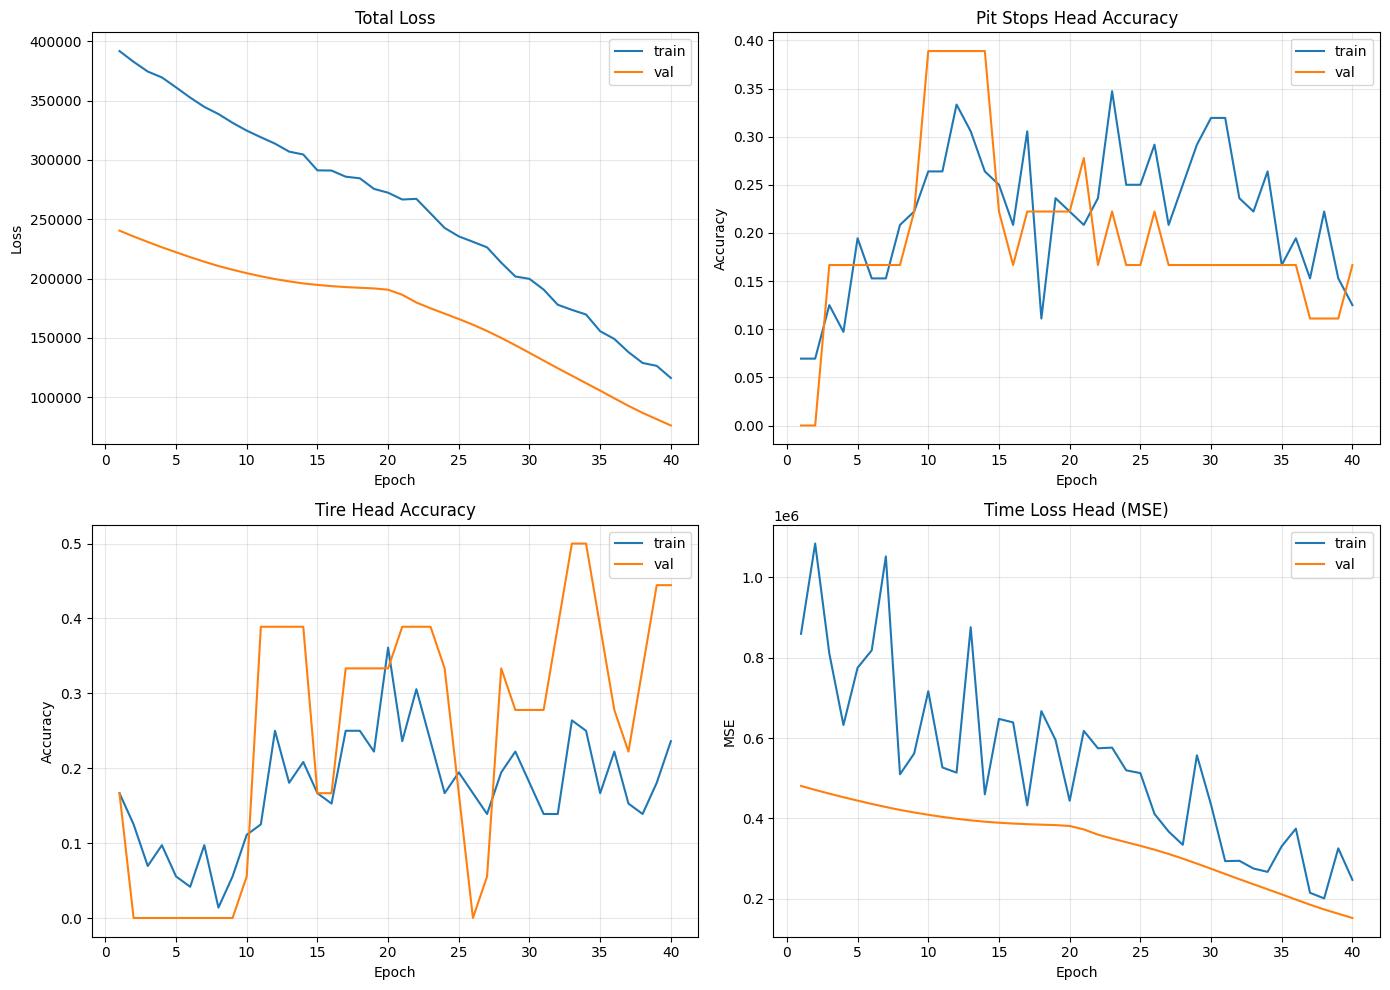

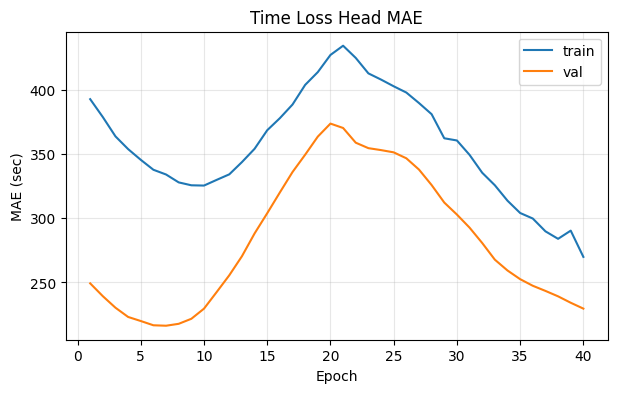

In [10]:
h = history.history
epochs = range(1, len(h["loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total loss
axes[0, 0].plot(epochs, h["loss"], label="train")
axes[0, 0].plot(epochs, h["val_loss"], label="val")
axes[0, 0].set_title("Total Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Stops accuracy
axes[0, 1].plot(epochs, h["stops_head_accuracy"], label="train")
axes[0, 1].plot(epochs, h["val_stops_head_accuracy"], label="val")
axes[0, 1].set_title("Pit Stops Head Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Tire accuracy
axes[1, 0].plot(epochs, h["tire_head_accuracy"], label="train")
axes[1, 0].plot(epochs, h["val_tire_head_accuracy"], label="val")
axes[1, 0].set_title("Tire Head Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Time head loss (MSE)
axes[1, 1].plot(epochs, h["time_head_loss"], label="train")
axes[1, 1].plot(epochs, h["val_time_head_loss"], label="val")
axes[1, 1].set_title("Time Loss Head (MSE)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("MSE")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional MAE plot for regression head
if "time_head_mae" in h and "val_time_head_mae" in h:
    plt.figure(figsize=(7,4))
    plt.plot(epochs, h["time_head_mae"], label="train")
    plt.plot(epochs, h["val_time_head_mae"], label="val")
    plt.title("Time Loss Head MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE (sec)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10) Save model + preprocessing

In [11]:
model.save(MODEL_FILE)

joblib.dump(
    {
        "team_encoder": team_enc,
        "track_encoder": track_enc,
        "start_comp_encoder": start_comp_enc,
        "stops_encoder": stops_enc,
        "tire_encoder": tire_enc,
        "num_cols": NUM_COLS,
        "weather_features": WEATHER_FEATURES,
        "max_timesteps": X_seq.shape[1],
    },
    PREPROC_FILE,
)

print("Saved:")
print(" -", MODEL_FILE)
print(" -", PREPROC_FILE)

Saved:
 - multitask_strategy_model.keras
 - multitask_preprocessing.joblib


## 11) Create example inference input files

In [12]:
race_context_example = pd.read_csv(RACE_CONTEXT_FILE)

forecast_example = pd.read_csv(FORECAST_FILE)

print("Wrote:")
print(" -", RACE_CONTEXT_FILE)
print(" -", FORECAST_FILE)

Wrote:
 - race_context_input.csv
 - forecast_weather.csv


## 12) Inference (single-scenario)

Outputs:
- predicted pit stop count
- predicted next/main tire compound
- predicted time loss (seconds)

You can then build per-pitstop compound sequencing logic on top (e.g., iterative decoding/simulation).

In [13]:
def encode_with_unknown(le, value):
    value = str(value)
    classes = set(le.classes_)
    if value in classes:
        return int(le.transform([value])[0])
    return 0


def build_forecast_sequence(forecast_df, weather_features, max_timesteps):
    f = forecast_df.copy()
    for c in weather_features:
        if c not in f.columns:
            f[c] = np.nan
        f[c] = pd.to_numeric(f[c], errors="coerce")

    f = f[weather_features].fillna(method="ffill").fillna(method="bfill").fillna(0.0)
    seq = f.values.astype("float32")

    seq_padded = pad_sequences([seq], maxlen=max_timesteps, padding="post", dtype="float32")
    return seq_padded


pre = joblib.load(PREPROC_FILE)
loaded_model = keras.models.load_model(MODEL_FILE)

rc = pd.read_csv(RACE_CONTEXT_FILE).iloc[0]
fw = pd.read_csv(FORECAST_FILE)

team_id = encode_with_unknown(pre["team_encoder"], rc["team_name"])
track_id = encode_with_unknown(pre["track_encoder"], rc["track_name"])
start_comp_id = encode_with_unknown(pre["start_comp_encoder"], str(rc["starting_compound"]).upper())

seq_input = build_forecast_sequence(fw, pre["weather_features"], pre["max_timesteps"])

# numeric context
weather_summary = {
    "air_temp_mean": float(pd.to_numeric(fw["air_temperature"], errors="coerce").mean()),
    "track_temp_mean": float(pd.to_numeric(fw["track_temperature"], errors="coerce").mean()),
    "humidity_mean": float(pd.to_numeric(fw["humidity"], errors="coerce").mean()),
    "rain_minutes_ratio": float((pd.to_numeric(fw["rainfall"], errors="coerce").fillna(0) > 0).mean()),
    "wind_speed_mean": float(pd.to_numeric(fw["wind_speed"], errors="coerce").mean()),
}
num_vals = np.array([
    float(rc.get("starting_position", 10)),
    weather_summary["air_temp_mean"],
    weather_summary["track_temp_mean"],
    weather_summary["humidity_mean"],
    weather_summary["rain_minutes_ratio"],
    weather_summary["wind_speed_mean"],
], dtype="float32").reshape(1, -1)

pred_stops, pred_tire, pred_time = loaded_model.predict(
    {
        "weather_seq": seq_input,
        "team_in": np.array([team_id], dtype=np.int32),
        "track_in": np.array([track_id], dtype=np.int32),
        "start_comp_in": np.array([start_comp_id], dtype=np.int32),
        "num_in": num_vals,
    },
    verbose=0,
)

stops_class = int(np.argmax(pred_stops[0]))
tire_class = int(np.argmax(pred_tire[0]))

stops_value = pre["stops_encoder"].inverse_transform([stops_class])[0]
tire_value = pre["tire_encoder"].inverse_transform([tire_class])[0]
time_loss_sec = float(pred_time[0][0])

print("\n--- PREDICTION ---")
print("Team:", rc["team_name"])
print("Track:", rc["track_name"])
print("Start position:", rc["starting_position"])
print("Start compound:", rc["starting_compound"])
print("\nPredicted pit stops:", stops_value, f"(conf={pred_stops[0][stops_class]:.3f})")
print("Predicted tire strategy class:", tire_value, f"(conf={pred_tire[0][tire_class]:.3f})")
print("Predicted time loss (s):", round(time_loss_sec, 3))

/var/folders/zb/tmbpzqhj4dxd92lmpmh07qv40000gn/T/ipykernel_64990/3996950627.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  f = f[weather_features].fillna(method="ffill").fillna(method="bfill").fillna(0.0)



--- PREDICTION ---
Team: Ferrari
Track: Imola
Start position: 4
Start compound: MEDIUM

Predicted pit stops: 1 (conf=0.488)
Predicted tire strategy class: MEDIUM (conf=0.979)
Predicted time loss (s): 10.611
